# Notebook 06 — Bivariate Phase 4: Five variable pairs (L6)

**Phase 4** — systematic bivariate Moran's I for selected continental-gradient pairs.

**Pairs** (x → spatial lag of y):
1. `ari × pre` — aridity vs precipitation (water-balance redundancy test)
2. `tmp × snw` — temperature vs snow cover (cryosphere decoupling)
3. `hdi × gdp` — HDI vs GDP (Band D socioeconomic redundancy)
4. `ele × slp` — mean elevation vs slope (topographic decoupling; Tibetan case)
5. `pre × aet` — precipitation vs AET (water- vs energy-limited regimes)

**Input**: `public.basin06` (L6, ~16k basins)  
**Regions**: Mediterranean, Monsoon Asia (Indomalaya), Tibetan/cold-arid — same as Phase 3  
**Conventions**: Queen weights `use_index=True`, row-standardised, seed=42, 999 permutations, no `plt.show()`.

In [1]:
# Cell 2 — imports
%matplotlib inline
import sys
from pathlib import Path

_p = Path.cwd()
while not (_p / 'CLAUDE.md').exists() and _p != _p.parent:
    _p = _p.parent
REPO = _p
sys.path.insert(0, str(REPO))
print(f'REPO = {REPO}')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from shapely import wkt

from libpysal.weights import Queen
from esda.moran import Moran_BV, Moran_Local_BV

from scripts.shared.db_utils import db_connect

SEED   = 42
N_PERM = 999
NODATA = -9999

print('Imports OK')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data loading

All nine analysis columns loaded in one query. BasinATLAS -9999 sentinels masked in `prepare()`.  
`tmp_dc_syr` stored as °C × 10 — scale factor 0.1 applied.

In [2]:
# Cell 4 — load basin06: geometry + all Phase 4 columns
import time
conn = db_connect()

SQL = """
SELECT hybas_id,
       ari_ix_sav, pre_mm_syr, tmp_dc_syr, snw_pc_syr,
       hdi_ix_sav, gdp_ud_sav, ele_mt_sav, slp_dg_sav, aet_mm_syr,
       ST_AsText(geom) AS geom_wkt
FROM public.basin06
ORDER BY hybas_id
"""
t0 = time.time()
with conn.cursor() as cur:
    cur.execute(SQL)
    rows = cur.fetchall()
conn.close()

cols = ['hybas_id','ari_ix_sav','pre_mm_syr','tmp_dc_syr','snw_pc_syr',
        'hdi_ix_sav','gdp_ud_sav','ele_mt_sav','slp_dg_sav','aet_mm_syr','geom_wkt']
df = pd.DataFrame(rows, columns=cols)
df['geometry'] = df['geom_wkt'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df.drop(columns='geom_wkt'), geometry='geometry', crs='EPSG:4326')
gdf = gdf.set_index('hybas_id')
print(f'{len(gdf):,} basins loaded in {time.time()-t0:.1f}s')

for col in ['ari_ix_sav','pre_mm_syr','tmp_dc_syr','snw_pc_syr',
            'hdi_ix_sav','gdp_ud_sav','ele_mt_sav','slp_dg_sav','aet_mm_syr']:
    sentinels = (gdf[col] == NODATA).sum()
    if sentinels:
        print(f'  {col}: {sentinels} sentinels (-9999)')

16,397 basins loaded in 2.7s
  snw_pc_syr: 5 sentinels (-9999)
  slp_dg_sav: 302 sentinels (-9999)


## Value preparation

Mask -9999 → NaN; apply scale factors; impute NaN with column mean (small counts only);  
log-transform where skewness > 5 AND min ≥ 0. Prepared values stored back in `gdf`.

In [3]:
# Cell 6 — prepare all nine columns
def prepare(series, scale_factor=1.0, label=''):
    v = series.copy().astype(float)
    v[v == NODATA] = np.nan
    v = v * scale_factor
    n_missing = v.isna().sum()
    if n_missing > 0:
        v = v.fillna(v.mean())
    skew = stats.skew(v)
    use_log = (skew > 5) and (v.min() >= 0)
    if use_log:
        v_final = np.log1p(np.clip(v, 0, None))
        skew_final = stats.skew(v_final)
    else:
        v_final = v
        skew_final = skew
    print(f'{label:12s}: skew={skew:6.2f}  log={str(use_log):5s}  '
          f'skew_after={skew_final:5.2f}  imputed={n_missing}')
    return v_final.values

gdf['ari'] = prepare(gdf['ari_ix_sav'], label='ari_ix_sav')
gdf['pre'] = prepare(gdf['pre_mm_syr'], label='pre_mm_syr')
gdf['tmp'] = prepare(gdf['tmp_dc_syr'], scale_factor=0.1, label='tmp_dc_syr')
gdf['snw'] = prepare(gdf['snw_pc_syr'], label='snw_pc_syr')
gdf['hdi'] = prepare(gdf['hdi_ix_sav'], label='hdi_ix_sav')
gdf['gdp'] = prepare(gdf['gdp_ud_sav'], label='gdp_ud_sav')
gdf['ele'] = prepare(gdf['ele_mt_sav'], label='ele_mt_sav')
gdf['slp'] = prepare(gdf['slp_dg_sav'], label='slp_dg_sav')
gdf['aet'] = prepare(gdf['aet_mm_syr'], label='aet_mm_syr')

ari_ix_sav  : skew=  7.87  log=True   skew_after=-0.95  imputed=0
pre_mm_syr  : skew=  1.65  log=False  skew_after= 1.65  imputed=0
tmp_dc_syr  : skew= -0.67  log=False  skew_after=-0.67  imputed=0
snw_pc_syr  : skew=  1.36  log=False  skew_after= 1.36  imputed=5
hdi_ix_sav  : skew= -0.65  log=False  skew_after=-0.65  imputed=0
gdp_ud_sav  : skew=  3.10  log=False  skew_after= 3.10  imputed=0
ele_mt_sav  : skew=  3.08  log=False  skew_after= 3.08  imputed=0
slp_dg_sav  : skew=  1.95  log=False  skew_after= 1.95  imputed=302
aet_mm_syr  : skew=  0.86  log=False  skew_after= 0.86  imputed=0


## Queen contiguity weights

In [4]:
# Cell 8 — build Queen weights (row-standardised, keyed by hybas_id)
import warnings
t0 = time.time()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    w = Queen.from_dataframe(gdf, use_index=True)
w.transform = 'r'
print(f'Weights built in {time.time()-t0:.1f}s')
print(f'n={w.n}  mean_neighbours={w.mean_neighbors:.2f}  islands={len(w.islands)}')

('WARNING: ', 1060034490.0, ' is an island (no neighbors)')
('WARNING: ', 1060034610.0, ' is an island (no neighbors)')
('WARNING: ', 1060034900.0, ' is an island (no neighbors)')
('WARNING: ', 1060035090.0, ' is an island (no neighbors)')
('WARNING: ', 1060040030.0, ' is an island (no neighbors)')
('WARNING: ', 1060040040.0, ' is an island (no neighbors)')
('WARNING: ', 1060040050.0, ' is an island (no neighbors)')
('WARNING: ', 1060040110.0, ' is an island (no neighbors)')
('WARNING: ', 1060040140.0, ' is an island (no neighbors)')
('WARNING: ', 1060040160.0, ' is an island (no neighbors)')
('WARNING: ', 1060040180.0, ' is an island (no neighbors)')
('WARNING: ', 2060044800.0, ' is an island (no neighbors)')
('WARNING: ', 2060045150.0, ' is an island (no neighbors)')
('WARNING: ', 2060046500.0, ' is an island (no neighbors)')
('WARNING: ', 2060047500.0, ' is an island (no neighbors)')
('WARNING: ', 2060048160.0, ' is an island (no neighbors)')
('WARNING: ', 2060048590.0, ' is an isla

## Global bivariate Moran's I — all five pairs

Expected signs before computing:
- `ari × pre`: positive (high aridity index = humid; humid basins in wet surroundings)
- `tmp × snw`: **negative** (warm basins in low-snow surroundings)
- `hdi × gdp`: positive (wealthy regions cluster together)
- `ele × slp`: positive globally but Tibetan Plateau should drive regional decoupling (high ele, low slp)
- `pre × aet`: positive (both track water availability), with energy-limited/water-limited boundary as decoupling zone

In [5]:
# Cell 10 — global bivariate Moran's I for all five pairs
PAIRS = [
    {'name': 'ari×pre', 'key': 'ari_pre', 'xv': 'ari', 'yv': 'pre',
     'xlabel': 'Aridity index', 'ylabel': 'Precipitation'},
    {'name': 'tmp×snw', 'key': 'tmp_snw', 'xv': 'tmp', 'yv': 'snw',
     'xlabel': 'Temperature',   'ylabel': 'Snow cover'},
    {'name': 'hdi×gdp', 'key': 'hdi_gdp', 'xv': 'hdi', 'yv': 'gdp',
     'xlabel': 'HDI',           'ylabel': 'GDP'},
    {'name': 'ele×slp', 'key': 'ele_slp', 'xv': 'ele', 'yv': 'slp',
     'xlabel': 'Elevation',     'ylabel': 'Slope'},
    {'name': 'pre×aet', 'key': 'pre_aet', 'xv': 'pre', 'yv': 'aet',
     'xlabel': 'Precipitation', 'ylabel': 'AET'},
]

global_rows = []
print('Global bivariate Moran\'s I (x → spatial lag of y, L6, 999 perms)')
print(f'  {"pair":10s}  {"I_BV":>8s}  {"p":>6s}  {"z":>7s}')
print('  ' + '-'*38)
for p in PAIRS:
    np.random.seed(SEED)
    bv = Moran_BV(gdf[p['xv']].values, gdf[p['yv']].values, w, permutations=N_PERM)
    p['bv'] = bv
    sig = '*' if bv.p_sim < 0.05 else 'NS'
    print(f'  {p["name"]:10s}  {bv.I:+8.4f}  {bv.p_sim:6.4f}  {bv.z_sim:+7.2f}  {sig}')
    global_rows.append({'pair': p['name'], 'I_BV': round(bv.I,4),
                        'p_sim': round(bv.p_sim,4), 'z_sim': round(bv.z_sim,2)})

global_df = pd.DataFrame(global_rows)
print()
print(global_df.to_string(index=False))

  ele×slp      +0.4226  0.0010   +52.00  *
  pre×aet      +0.8632  0.0010  +107.73  *

   pair    I_BV  p_sim   z_sim
ari×pre  0.5780  0.001   69.28
tmp×snw -0.8649  0.001 -106.76
hdi×gdp  0.5805  0.001   72.96
ele×slp  0.4226  0.001   52.00
pre×aet  0.8632  0.001  107.73


## Local bivariate LISA — all five pairs

In [6]:
# Cell 12 — local bivariate LISA for all five pairs
import warnings
QUAD_MAP = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}

print('Bivariate LISA class counts (p < 0.05)')
for p in PAIRS:
    np.random.seed(SEED)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')  # suppress 0-variance z_sim for islands
        lbv = Moran_Local_BV(gdf[p['xv']].values, gdf[p['yv']].values,
                             w, permutations=N_PERM, seed=SEED)
    p['lbv'] = lbv
    sig = lbv.p_sim < 0.05
    cls_arr = np.where(sig, np.vectorize(QUAD_MAP.get)(lbv.q), 'NS')
    gdf[f'bv_{p["key"]}'] = cls_arr
    counts = pd.Series(cls_arr).value_counts()
    total = len(gdf)
    parts = '  '.join(f'{c}={counts.get(c,0)/total*100:.1f}%' for c in ['HH','LL','HL','LH','NS'])
    print(f'  {p["name"]:10s}  {parts}')

  pre×aet     HH=22.3%  LL=29.4%  HL=1.9%  LH=0.0%  NS=46.3%


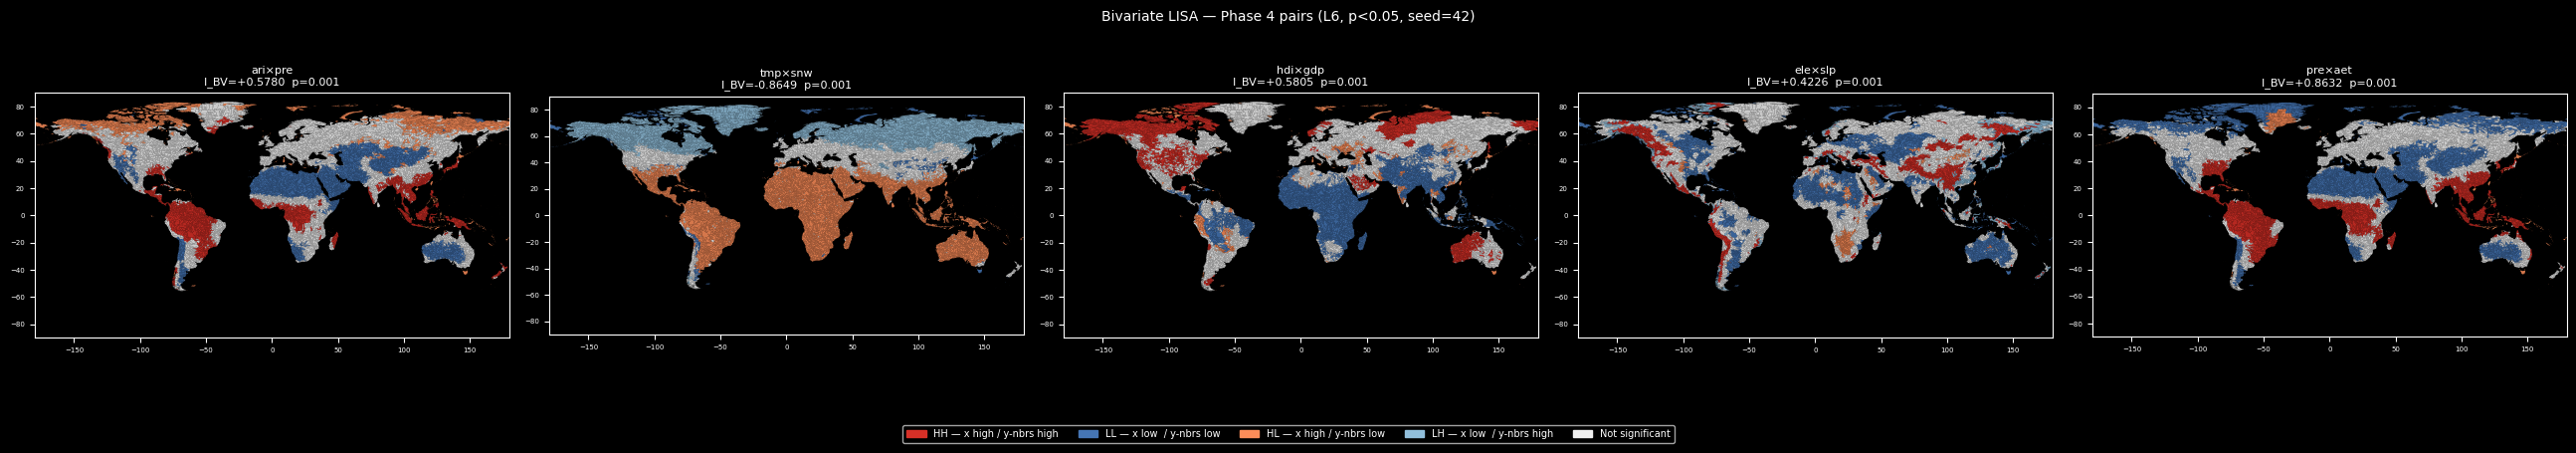

In [7]:
# Cell 13 — global LISA maps: 1×5 panel
CLASS_COLOURS = {'HH':'#d73027','LL':'#4575b4','HL':'#fc8d59','LH':'#91bfdb','NS':'#f0f0f0'}
CLASS_ORDER   = ['HH','LL','HL','LH','NS']
CLASS_LABELS  = {
    'HH': 'HH — x high / y-nbrs high',
    'LL': 'LL — x low  / y-nbrs low',
    'HL': 'HL — x high / y-nbrs low',
    'LH': 'LH — x low  / y-nbrs high',
    'NS': 'Not significant',
}

fig, axes = plt.subplots(1, 5, figsize=(26, 4))
for ax, p in zip(axes, PAIRS):
    col = f'bv_{p["key"]}'
    for cls in CLASS_ORDER:
        sub = gdf[gdf[col] == cls]
        if len(sub):
            sub.plot(ax=ax, color=CLASS_COLOURS[cls], linewidth=0, alpha=0.85)
    row = global_df[global_df['pair'] == p['name']].iloc[0]
    sig_str = f'p={row.p_sim}' if row.p_sim < 0.05 else f'p={row.p_sim} NS'
    ax.set_title(f"{p['name']}\nI_BV={row.I_BV:+.4f}  {sig_str}", fontsize=8)
    ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.tick_params(labelsize=5)

handles = [mpatches.Patch(color=CLASS_COLOURS[c], label=CLASS_LABELS[c]) for c in CLASS_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=7,
           bbox_to_anchor=(0.5, -0.12))
fig.suptitle('Bivariate LISA — Phase 4 pairs (L6, p<0.05, seed=42)', fontsize=10)
plt.tight_layout()
plt.savefig(REPO / 'spatial' / 'bivariate_ph4_global.png', dpi=150, bbox_inches='tight')
print('Saved → spatial/bivariate_ph4_global.png')

## Regional stratification

Same three regions as Phase 3 — loaded from the OneEarth hierarchy, assigned by polygon intersection.
Per-pair × per-region I_BV run on subset weights; islands dropped if any.

In [8]:
# Cell 15 — load ecoregion polygons and assign regions to basins
conn = db_connect()

SQL_ECO = """
SELECT DISTINCT e.eco_id, s.subrealm_n, r.realm,
       ST_AsText(e.geom) AS geom_wkt
FROM gaz."Ecoregions2017" e
JOIN gaz."Bioregions2023" b ON b.bioregions = e.bioregion
JOIN gaz."Subrealm2023"  s ON s.subrealmid  = b.subrealm_id
JOIN gaz."Realm2023"     r ON r.biogeorelm  = s.biogeorelm
WHERE s.subrealm_n = 'Mediterranean'
   OR r.realm      = 'Indomalaya'
   OR s.subrealm_n = 'Himalayas & Tibetan Plateau'
"""
with conn.cursor() as cur:
    cur.execute(SQL_ECO)
    eco_rows = cur.fetchall()
conn.close()
print(f'{len(eco_rows)} ecoregion rows loaded')

eco_df = pd.DataFrame(eco_rows, columns=['eco_id','subrealm_n','realm','geom_wkt'])
eco_df['geometry'] = eco_df['geom_wkt'].apply(wkt.loads)
eco_gdf = gpd.GeoDataFrame(eco_df.drop(columns='geom_wkt'), geometry='geometry', crs='EPSG:4326')

def assign_region(row):
    if row['subrealm_n'] == 'Mediterranean':           return 'Mediterranean'
    if row['realm']      == 'Indomalaya':              return 'Monsoon Asia'
    return 'Tibetan/cold-arid'

eco_gdf['region'] = eco_gdf.apply(assign_region, axis=1)
print('Ecoregion polygons per region:')
print(eco_gdf['region'].value_counts().to_string())

import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    joined = gpd.sjoin(gdf[['geometry']], eco_gdf[['region','geometry']],
                       how='left', predicate='intersects')
joined = joined[~joined.index.duplicated(keep='first')]
gdf['region'] = joined['region']
print('\nBasin counts per region:')
print(gdf['region'].value_counts(dropna=False).to_string())


Basin counts per region:
region
NaN                  14712
Monsoon Asia          1087
Tibetan/cold-arid      369
Mediterranean          229


In [9]:
# Cell 16 — per-pair × per-region bivariate Moran's I
REGIONS = ['Mediterranean', 'Monsoon Asia', 'Tibetan/cold-arid']
regional_rows = []

for p in PAIRS:
    print(f"\n{p['name']}")
    for region in REGIONS:
        sub = gdf[gdf['region'] == region].copy()
        if len(sub) < 30:
            print(f'  {region}: n={len(sub)} — skip')
            continue
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            w_sub = Queen.from_dataframe(sub, use_index=True)
            if w_sub.islands:
                sub = sub.drop(index=w_sub.islands)
                w_sub = Queen.from_dataframe(sub, use_index=True)
        w_sub.transform = 'r'
        np.random.seed(SEED)
        bv_sub = Moran_BV(sub[p['xv']].values, sub[p['yv']].values,
                          w_sub, permutations=N_PERM)
        sig = '*' if bv_sub.p_sim < 0.05 else 'NS'
        print(f'  {region:22s}: n={len(sub):4d}  I_BV={bv_sub.I:+.4f}  p={bv_sub.p_sim:.4f}  {sig}')
        regional_rows.append({
            'pair': p['name'], 'region': region, 'n': len(sub),
            'I_BV': round(bv_sub.I, 4), 'p_sim': round(bv_sub.p_sim, 4),
        })

reg_df = pd.DataFrame(regional_rows)
print('\n--- I_BV pivot (pairs × regions) ---')
pivot = reg_df.pivot(index='pair', columns='region', values='I_BV')
print(pivot.to_string())
print('\n--- p_sim pivot ---')
pivot_p = reg_df.pivot(index='pair', columns='region', values='p_sim')
print(pivot_p.to_string())

  Tibetan/cold-arid     : n= 369  I_BV=+0.7525  p=0.0010  *

--- I_BV pivot (pairs × regions) ---
region   Mediterranean  Monsoon Asia  Tibetan/cold-arid
pair                                                   
ari×pre         0.8241        0.8133             0.6259
ele×slp         0.0621        0.4845            -0.1414
hdi×gdp         0.6880        0.4221             0.6202
pre×aet         0.8364        0.8537             0.7525
tmp×snw        -0.4703       -0.2173            -0.0045

--- p_sim pivot ---
region   Mediterranean  Monsoon Asia  Tibetan/cold-arid
pair                                                   
ari×pre          0.001         0.001              0.001
ele×slp          0.114         0.001              0.002
hdi×gdp          0.001         0.001              0.001
pre×aet          0.001         0.001              0.001
tmp×snw          0.001         0.001              0.459


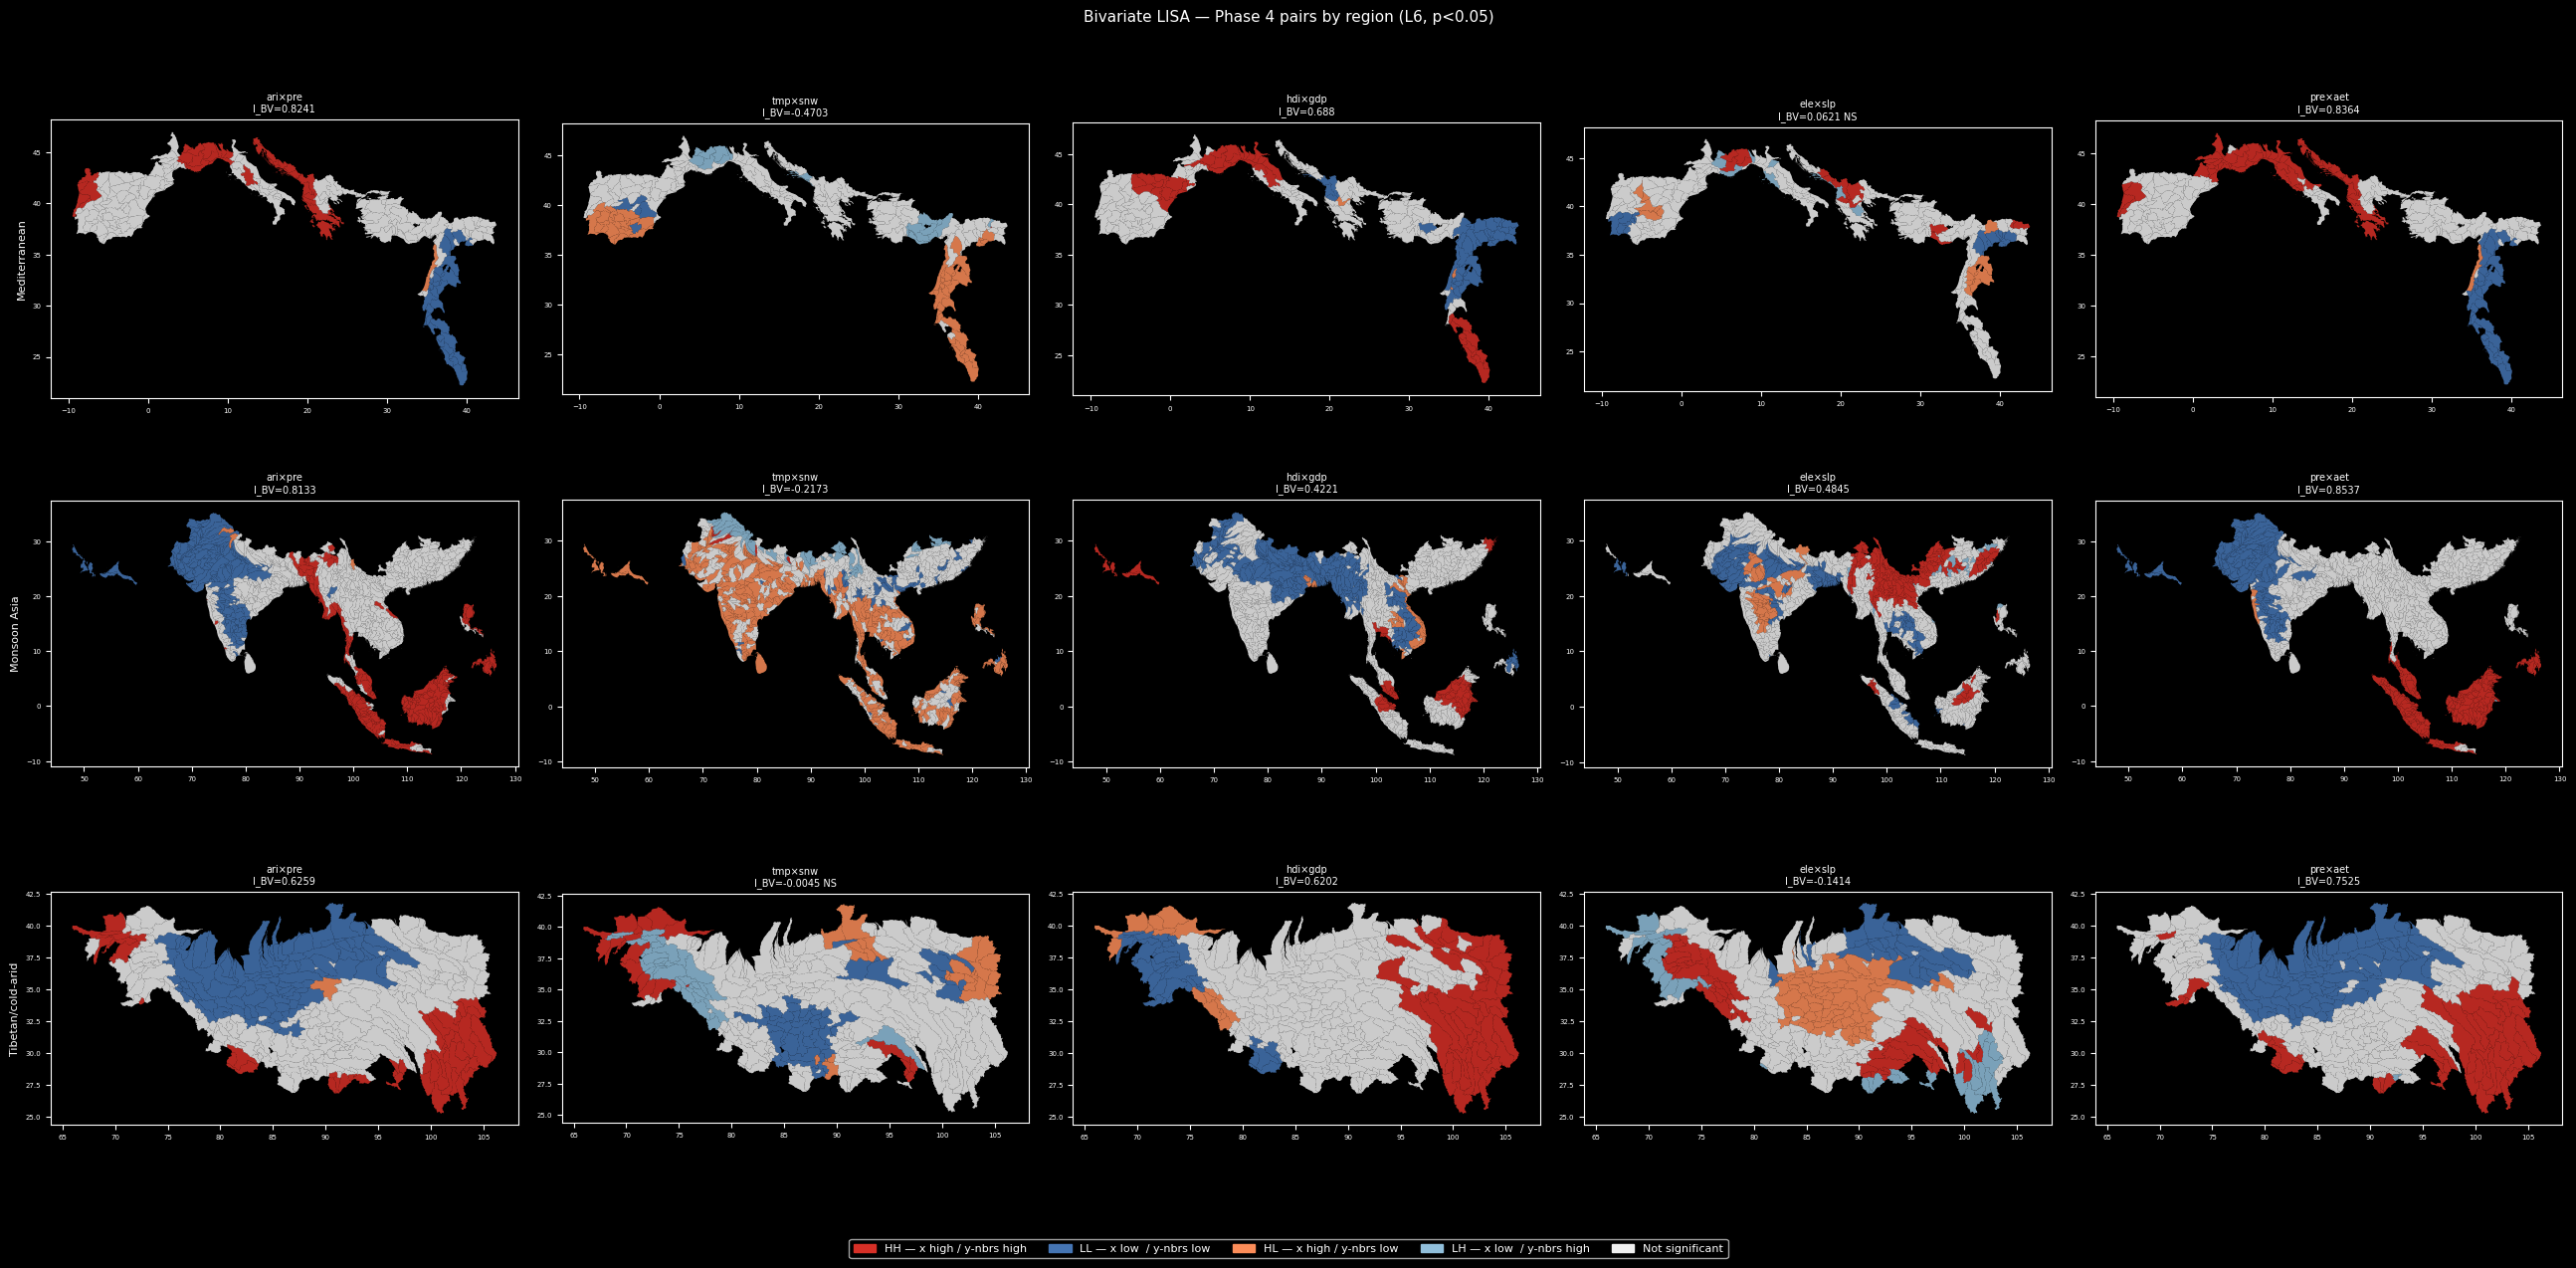

In [10]:
# Cell 17 — regional LISA maps: 3 rows (regions) × 5 columns (pairs)
fig, axes = plt.subplots(3, 5, figsize=(26, 12))

for row_i, region in enumerate(REGIONS):
    sub_full = gdf[gdf['region'] == region].copy()
    if len(sub_full) < 30:
        for ax in axes[row_i]:
            ax.set_title(f'{region}\n(insufficient data)', fontsize=7)
        continue

    for col_i, p in enumerate(PAIRS):
        ax = axes[row_i, col_i]
        sub = sub_full.copy()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            w_sub = Queen.from_dataframe(sub, use_index=True)
            if w_sub.islands:
                sub = sub.drop(index=w_sub.islands)
                w_sub = Queen.from_dataframe(sub, use_index=True)
        w_sub.transform = 'r'
        np.random.seed(SEED)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            lbv_sub = Moran_Local_BV(sub[p['xv']].values, sub[p['yv']].values,
                                     w_sub, permutations=N_PERM, seed=SEED)
        sig = lbv_sub.p_sim < 0.05
        sub = sub.copy()
        sub['bv_cls'] = np.where(sig, np.vectorize(QUAD_MAP.get)(lbv_sub.q), 'NS')

        for cls in CLASS_ORDER:
            s = sub[sub['bv_cls'] == cls]
            if len(s):
                s.plot(ax=ax, color=CLASS_COLOURS[cls], linewidth=0, alpha=0.85)

        reg_row = reg_df[(reg_df['pair']==p['name']) & (reg_df['region']==region)]
        i_bv = reg_row['I_BV'].values[0] if len(reg_row) else 'n/a'
        p_val = reg_row['p_sim'].values[0] if len(reg_row) else ''
        ns_tag = '' if (isinstance(p_val, float) and p_val < 0.05) else ' NS'
        ax.set_title(f"{p['name']}\nI_BV={i_bv}{ns_tag}", fontsize=7)
        ax.tick_params(labelsize=5)
        if col_i == 0:
            ax.set_ylabel(region, fontsize=8)

handles = [mpatches.Patch(color=CLASS_COLOURS[c], label=CLASS_LABELS[c]) for c in CLASS_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Bivariate LISA — Phase 4 pairs by region (L6, p<0.05)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(REPO / 'spatial' / 'bivariate_ph4_regions.png', dpi=150, bbox_inches='tight')
print('Saved → spatial/bivariate_ph4_regions.png')

## Summary findings — Phase 4

### Global I_BV and LISA class summary

| Pair | I_BV | HH% | LL% | HL% | LH% | NS% | Tier |
|---|---|---|---|---|---|---|---|
| tmp×snw | −0.865 | 0.0 | 1.8 | **51.5** | **22.6** | 24.2 | Near-redundant |
| pre×aet | +0.863 | **22.3** | **29.4** | 1.9 | 0.0 | 46.3 | Near-redundant |
| hdi×gdp | +0.581 | 13.9 | **30.5** | 4.0 | 0.0 | 51.7 | Genuinely distinct |
| ari×pre | +0.578 | 16.6 | **24.3** | 7.9 | 0.0 | 51.1 | Genuinely distinct |
| ele×slp | +0.423 | 10.8 | **26.2** | 3.3 | 4.6 | 55.1 | Genuinely distinct |

---

### Pair summaries (global)

**ari×pre (+0.578)** — not redundant. The 7.9% HL maps onto the subarctic/arctic: basins with high aridity index (humid, because PET is very low due to cold temperatures) in moderate-precipitation surroundings. The T-mediated PET term creates genuine geographic divergence between cold-arid and hot-arid worlds. Both variables needed.

**tmp×snw (−0.865)** — near-redundant. The map is a latitude partition: warm=snow-free (HL, 51.5%), cold=snowy (LH, 22.6%), almost everywhere on Earth. The only exceptions — the NS transition band (35–60°N, where seasonality decouples annual mean T from winter snow) and altitude-driven anomalies (Andes, Tibetan Plateau) — are precisely where historical polities are densest.

**hdi×gdp (+0.581)** — not redundant, and partly CDOP territory. Russia HH (Soviet human capital legacy), Sub-Saharan Africa the largest coherent LL zone globally, HL patches in former Soviet Central Asia and middle-income South America. The moderate I_BV reflects real institutional and historical divergence that physical geography cannot explain. Band D LISA interpretations require historical-cultural context.

**ele×slp (+0.423)** — genuinely distinct. The dominant HL signal is the **African Plateau**, not the Tibetan Plateau as predicted. Africa's "plateau continent" character (ancient basement rock at 500–2000m, low relief) produces a larger HL footprint than Tibet. Mountain ranges (HH), lowland plains (LL), and plateau environments (HL) require both variables to distinguish.

**pre×aet (+0.863)** — near-redundant globally, with one important exception. The **Mediterranean is NS** — annual totals are moderate on both variables, hiding the summer drought. Cold subarctic = LL (low absolute precip AND low AET), consistent with ari×pre HL for the same zone. The 1.9% HL = cold maritime coasts (S Norway, S Chile) where energy limitation suppresses AET below precipitation.

---

### Regional I_BV grid (3 regions × 5 pairs)

Region sample sizes: Mediterranean n=221, Monsoon Asia n=1046, Tibetan/cold-arid n=369. NS = not significant (p > 0.05); all other cells p = 0.001–0.002.

| Pair | Mediterranean | Monsoon Asia | Tibetan/cold-arid | Global |
|---|---|---|---|---|
| ari×pre | +0.824 | +0.813 | +0.626 | +0.578 |
| tmp×snw | −0.470 | −0.217 | **−0.005 NS** | −0.865 |
| hdi×gdp | +0.688 | +0.422 | +0.620 | +0.581 |
| ele×slp | **+0.062 NS** | +0.485 | **−0.141** | +0.423 |
| pre×aet | +0.836 | +0.854 | +0.753 | +0.863 |

---

### Regional pair notes

**ari×pre** — amplified in all three regions; no reversal (contrast with T×P in Phase 3). All regions exceed the global value. Monsoon Asia map: bimodal geographic partition — Indian subcontinent LL (semi-arid, both metrics below regional mean) vs equatorial SE Asia HH (perennially wet). The summer-drought mechanism that inverts T×P in the Mediterranean cannot invert ari×pre because both variables track the same moisture signal.

**tmp×snw** — progressive decoupling: −0.865 → −0.470 → −0.217 → **−0.005 NS**. Within the Tibetan/cold-arid zone, all basins are cold (temperature variance compressed) and snow distribution is governed by precipitation (monsoon vs dry interior), not temperature. The globally near-redundant pair is locally independent in cold-arid regions. **The "near-redundant" tier does not hold for high-altitude or cold-arid sites.**

**hdi×gdp** — all regions significant; Mediterranean (+0.688) and Tibetan (+0.620) exceed global (+0.581). Coherent socioeconomic sub-region geography within both zones. CDOP boundary implication reinforced.

**ele×slp** — three structurally distinct patterns. Mediterranean NS (+0.062): heterogeneous patchwork, ele and slp spatially independent. Tibetan sign reversal (−0.141): plateau interior — elevated but flat, surrounded by flat neighbours — HL class expressed as negative regional I_BV (confirms BV.11). Monsoon Asia amplified (+0.485): Himalayan orogeny creates coherent HH/LL mountain-lowland contrast.

**pre×aet** — most geographically stable pair (range 0.753–0.854); no reversal, no NS. Mediterranean paradox resolved: global NS reflects distribution position; regional I_BV = +0.836 reflects the within-region wet-to-dry gradient (N Italy/France → Levantine coast). Syria/Lebanon coastal HL patch: orographic high-P basins surrounded by low-AET Syrian semi-arid interior. The historically dense Mediterranean heartland (Spain, central Italy, Greece) is NS even within the region — annual pre and aet provide minimal discriminating power for classical-period sites.

---

### Cross-regional synthesis: stable vs context-dependent pairs

| Pair | Global tier | Regional stability |
|---|---|---|
| pre×aet (+0.863) | Near-redundant | **Stable** — holds in all regions |
| tmp×snw (−0.865) | Near-redundant | **Context-dependent** — collapses to NS in Tibetan |
| hdi×gdp (+0.581) | Genuinely distinct | **Stable** — amplified or comparable in all regions |
| ari×pre (+0.578) | Genuinely distinct | **Stable** — amplified in all regions |
| ele×slp (+0.423) | Genuinely distinct | **Context-dependent** — NS in Mediterranean, sign reversal in Tibetan |

Three pairs stable; two context-dependent. For polity-phase variable selection, tier assignments for tmp×snw and ele×slp carry a regional qualifier.

---

### Cross-pair insight: LISA class = global structural position, not absolute character

The subarctic zone is classified differently by two pairs:
- `ari×pre`: **HL** — high aridity index (P/PET high because PET is very low), moderate-precip neighbourhood
- `pre×aet`: **LL** — low absolute precipitation AND low AET, both below global mean

Both are internally consistent. LISA class always expresses position in the global distribution; two variables can assign different classes to the same geography without contradiction. Raw signature values are essential alongside LISA class.

*Formal entries: `spatial/esda_findings.md` BV.7–BV.19.*